# 03 US Model Training & Comparison

Train and compare:
- LogisticRegression
- RandomForestClassifier
- GradientBoostingClassifier
- XGBClassifier

Evaluation: StratifiedKFold(5) with macro-averaged metrics.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.model import set_seed, compare_models, MODELS, train_and_evaluate
from src.features import set_seed as feat_set_seed

set_seed(42)

## Load Prepared Data

In [2]:
df = pd.read_csv('../data/processed/us_modeling_ready.csv')
print('Shape:', df.shape)
print('Label distribution:')
print(df['potential_label'].value_counts().sort_index())

X = df.drop(columns=['potential_label']).values
y = df['potential_label'].values
feature_names = df.drop(columns=['potential_label']).columns.tolist()
print(f'\nFeatures: {len(feature_names)}')

Shape: (72537, 50)
Label distribution:
potential_label
0    24279
1    24174
2    24084
Name: count, dtype: int64

Features: 49


## Cross-Validation Model Comparison

In [3]:
results_df = compare_models(X, y, cv=5, scale_lr=True)
print(results_df.to_string(index=False))
results_df.to_csv('../outputs/results/model_comparison.csv', index=False)
print('\nSaved to outputs/results/model_comparison.csv')

C:\Users\User\Desktop\SolarPotentialMapping\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\User\Desktop\SolarPotentialMapping\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\User\Desktop\SolarPotentialMapping\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\User\Desktop\SolarPotentialMapping\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect

             model  accuracy  f1_macro  roc_auc_ovr  precision_macro  recall_macro
LogisticRegression  0.600080  0.597589     0.781752         0.596108      0.600007
      RandomForest  0.685678  0.687392     0.851912         0.689909      0.685562
  GradientBoosting  0.685071  0.685954     0.851398         0.687250      0.684918
           XGBoost  0.699905  0.701219     0.864087         0.703073      0.699766

Saved to outputs/results/model_comparison.csv


## Visualize Model Comparison

C:\Users\User\AppData\Local\Temp\ipykernel_13644\1068586588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='muted')
C:\Users\User\AppData\Local\Temp\ipykernel_13644\1068586588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='muted')
C:\Users\User\AppData\Local\Temp\ipykernel_13644\1068586588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='muted')
C:\Users\User\AppData\Loc

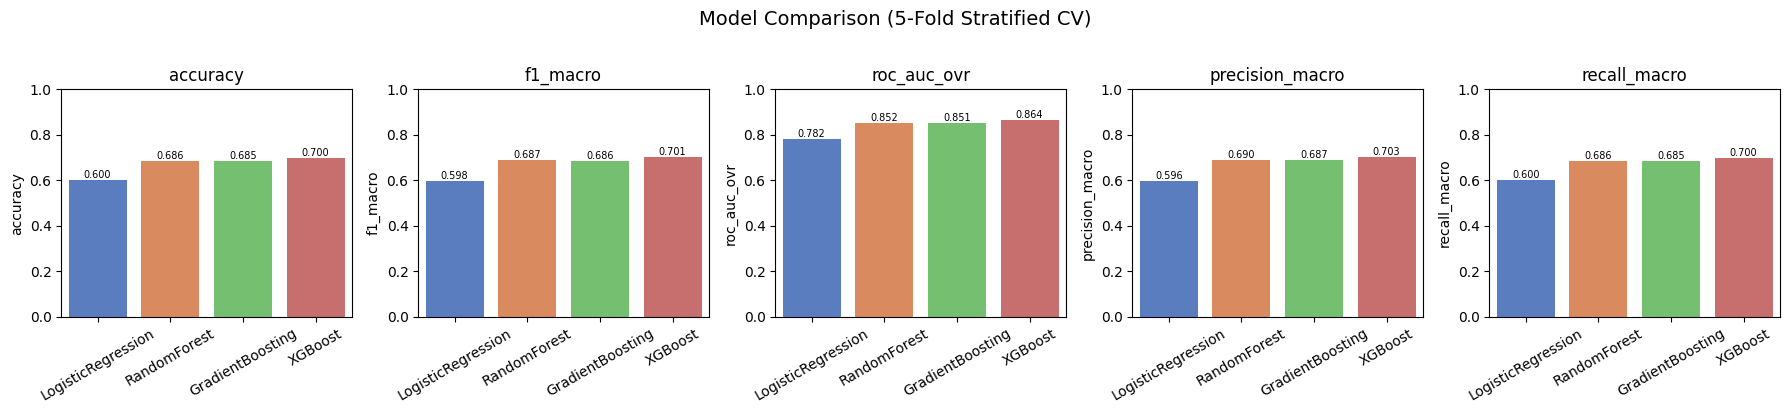

In [4]:
metrics_to_plot = ['accuracy', 'f1_macro', 'roc_auc_ovr', 'precision_macro', 'recall_macro']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='muted')
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7)

plt.suptitle('Model Comparison (5-Fold Stratified CV)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Train Best Model on Full Data & Feature Importance

In [5]:
# Pick best by f1_macro
best_model_name = results_df.loc[results_df['f1_macro'].idxmax(), 'model']
print(f'Best model by F1-macro: {best_model_name}')

best_model = MODELS[best_model_name]

# Scale for LR
if best_model_name == 'LogisticRegression':
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    best_model.fit(X_scaled, y)
else:
    best_model.fit(X, y)
    X_scaled = None

Best model by F1-macro: XGBoost


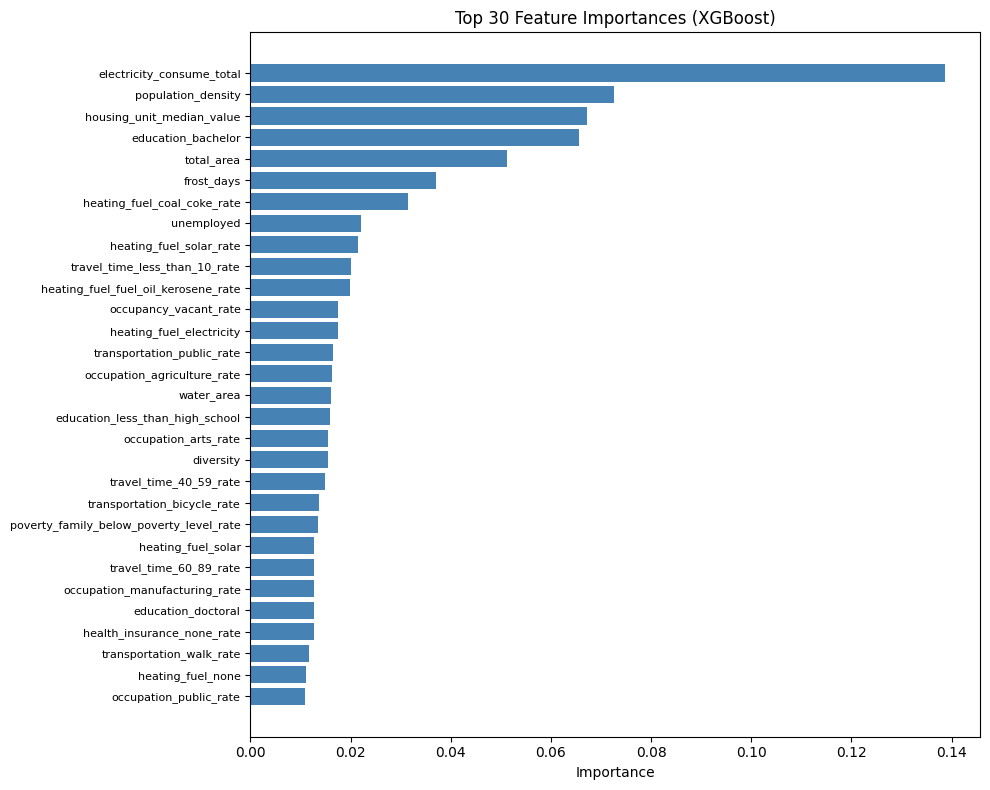

Saved to outputs/results/feature_importance.csv


In [6]:
# Feature importance / coefficients
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_).mean(axis=0)
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(30, len(feat_imp))
    ax.barh(range(top_n), feat_imp['importance'].head(top_n), color='steelblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(feat_imp['feature'].head(top_n), fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.savefig('../outputs/figures/03_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    feat_imp.to_csv('../outputs/results/feature_importance.csv', index=False)
    print('Saved to outputs/results/feature_importance.csv')

## Hold-out Validation: Confusion Matrix & Report

In [7]:
# Train/test split for interpretability
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

val_model = type(best_model)(**best_model.get_params())
if best_model_name == 'LogisticRegression':
    scaler_val = StandardScaler()
    X_train_s = scaler_val.fit_transform(X_train)
    X_test_s = scaler_val.transform(X_test)
    val_model.fit(X_train_s, y_train)
    y_pred = val_model.predict(X_test_s)
else:
    val_model.fit(X_train, y_train)
    y_pred = val_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Saturated (0)', 'Medium (1)', 'High (2)']))

               precision    recall  f1-score   support

Saturated (0)       0.83      0.79      0.81      4856
   Medium (1)       0.58      0.58      0.58      4835
     High (2)       0.69      0.71      0.70      4817

     accuracy                           0.70     14508
    macro avg       0.70      0.70      0.70     14508
 weighted avg       0.70      0.70      0.70     14508



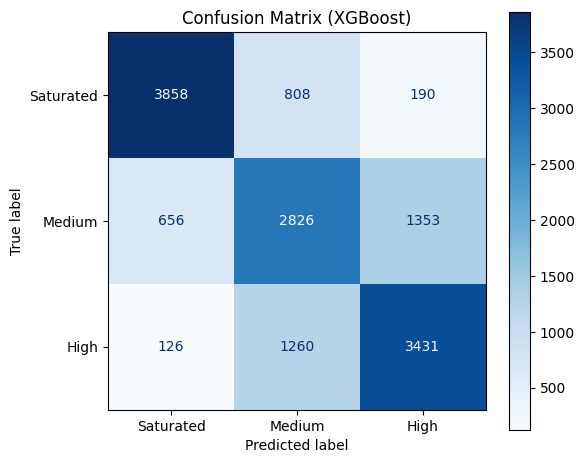

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saturated', 'Medium', 'High'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix ({best_model_name})')
plt.tight_layout()
plt.savefig('../outputs/figures/03_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Best Model

In [9]:
import pickle

model_bundle = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_names': feature_names,
    'scaler': X_scaled,  # None if not LR
}
if best_model_name == 'LogisticRegression':
    model_bundle['scaler'] = scaler

with open('../outputs/results/best_us_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print('Saved to outputs/results/best_us_model.pkl')

Saved to outputs/results/best_us_model.pkl
